In [11]:
import os
import cv2
import numpy as np
import kagglehub
import time
from skimage.feature import hog
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================
# ETAPA 1: Download e Localização dos Dados
# ==========================================
def carregar_dataset():
    print("\n[ETAPA 1] Baixando/Localizando dataset via Kagglehub...")
    inicio = time.time()

    # Faz o download da base de dados do Kaggle
    path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")
    dataset_path = os.path.join(path, "original")

    if not os.path.exists(dataset_path):
        dataset_path = path

    # Mapeia todas as pastas que representam as classes do lixo
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    tempo = round(time.time() - inicio, 2)
    print(f"[OK] ETAPA 1 Concluída em {tempo}s.")
    return dataset_path, classes


In [12]:
# ==========================================
# ETAPA 2: Extração Avançada (HOG + HSV)
# ==========================================
def extrair_features(dataset_path, classes):
    print("\n[ETAPA 2] Iniciando extração de características (Forma + Cor)...")
    print(" -> Isso vai demorar um pouco mais, pois estamos extraindo cores também.")
    inicio = time.time()

    X = [] # Matriz de atributos numéricos
    y = [] # Vetor de rótulos (classes)

    for classe in classes:
        pasta_classe = os.path.join(dataset_path, classe)
        arquivos = os.listdir(pasta_classe)
        print(f" -> Processando '{classe}'...")

        for arquivo in arquivos:
            caminho_imagem = os.path.join(pasta_classe, arquivo)
            try:
                img = cv2.imread(caminho_imagem)
                if img is None: continue

                # Redimensiona para garantir padronização (64x64)
                img_resized = cv2.resize(img, (64, 64))

                # --- MELHORIA 1.1: EXTRAÇÃO DE FORMA (HOG) ---
                gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
                features_hog = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                                   cells_per_block=(2, 2), block_norm='L2-Hys')

                # --- MELHORIA 1.2: EXTRAÇÃO DE COR (HSV) ---
                # Converte para HSV (Matiz, Saturação, Valor) que lida melhor com luz
                hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
                # Calcula o histograma 3D separando as cores em 8 faixas
                hist_cor = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256])
                # Normaliza e "achata" a matriz em um vetor 1D
                features_cor = cv2.normalize(hist_cor, hist_cor).flatten()

                # --- MELHORIA 1.3: FUSÃO (EARLY FUSION) ---
                # Une os números do contorno com os números da cor
                features_finais = np.hstack((features_hog, features_cor))

                X.append(features_finais)
                y.append(classe)
            except Exception:
                pass

    X = np.array(X)
    y = np.array(y)

    tempo = round(time.time() - inicio, 2)
    print(f"[OK] ETAPA 2 Concluída em {tempo}s.")
    print(f" -> Tamanho do novo vetor HOG+HSV: {X.shape[1]} atributos")
    return X, y

In [13]:
# ==========================================
# ETAPA 3: Divisão dos Dados (80% Treino / 20% Teste)
# ==========================================
def dividir_dados(X, y):
    print("\n[ETAPA 3] Dividindo a base de dados (8/10 Treino, 2/10 Teste)...")
    inicio = time.time()

    # test_size=0.2 garante os 20% para teste solicitados
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    tempo = round(time.time() - inicio, 2)
    print(f"[OK] ETAPA 3 Concluída em {tempo}s.")
    print(f" -> Volume de Treinamento (80%): {len(X_train)} amostras")
    print(f" -> Volume de Teste (20%): {len(X_test)} amostras")

    return X_train, X_test, y_train, y_test

In [14]:
# ==========================================
# ETAPA 4: Treinamento Otimizado (GridSearch)
# ==========================================
def treinar_svm(X_train, y_train):
    print("\n[ETAPA 4] Buscando os melhores parâmetros e treinando o SVM...")
    inicio = time.time()

    # --- MELHORIA 2: GRID SEARCH ---
    # Define as combinações que o Python vai testar para achar a melhor IA
    parametros = {
        'C': [10, 50],         # Margem de tolerância a erros
        'kernel': ['rbf'],     # Modelo curvo espacial
        'gamma': ['scale']     # Ajuste automático ao número de características
    }

    svm_base = svm.SVC()
    # n_jobs=-1 faz o Python usar todos os núcleos do processador para ser mais rápido
    grid_search = GridSearchCV(svm_base, parametros, cv=3, n_jobs=-1, verbose=2)
    grid_search.fit(X_train, y_train)

    tempo = round(time.time() - inicio, 2)
    print(f"\n[OK] ETAPA 4 Concluída em {tempo}s.")
    print(f" -> O modelo SVM aprendeu as regras usando os parâmetros: {grid_search.best_params_}")

    return grid_search.best_estimator_ # Retorna apenas a melhor IA encontrada

In [15]:
# ==========================================
# ETAPA 5: Avaliação e Resultados
# ==========================================
def avaliar_modelo(modelo, X_test, y_test):
    print("\n[ETAPA 5] Gerando relatório de predições...")
    predicoes = modelo.predict(X_test)
    print("\n================ RELATÓRIO DE CLASSIFICAÇÃO ================")
    print(classification_report(y_test, predicoes))
    return predicoes

In [16]:
# ==========================================
# ETAPA 6: Matriz de Confusão
# ==========================================
def plotar_matriz_confusao(y_test, predicoes, classes):
    print("\n[ETAPA 6] Gerando e salvando a Matriz de Confusão...")

    # Garante que as classes estejam em ordem alfabética para o gráfico fazer sentido
    classes_ordenadas = sorted(classes)

    # Calcula a matriz
    cm = confusion_matrix(y_test, predicoes, labels=classes_ordenadas)

    # Configurações visuais do gráfico
    fig, ax = plt.subplots(figsize=(10, 8)) # Tamanho da imagem
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_ordenadas)

    # Plota a matriz usando tons de azul
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

    plt.title('Matriz de Confusão - SVM HOG Reciclagem', fontsize=14, pad=20)
    plt.tight_layout() # Ajusta as margens

    # Salva a imagem para você usar no seu portfólio/GitHub
    nome_arquivo = 'matriz_confusao.png'
    plt.savefig(nome_arquivo, dpi=300)
    print(f"[OK] ETAPA 6 Concluída! Gráfico salvo como '{nome_arquivo}'.")

    # Exibe a janela com o gráfico
    plt.show()

--- INICIANDO SISTEMA DE CLASSIFICAÇÃO DE RESÍDUOS SÓLIDOS (V2.0) ---

[ETAPA 1] Baixando/Localizando dataset via Kagglehub...
Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
[OK] ETAPA 1 Concluída em 2.5s.

[ETAPA 2] Iniciando extração de características (Forma + Cor)...
 -> Isso vai demorar um pouco mais, pois estamos extraindo cores também.
 -> Processando 'metal'...
 -> Processando 'glass'...
 -> Processando 'biological'...
 -> Processando 'paper'...
 -> Processando 'battery'...
 -> Processando 'trash'...
 -> Processando 'cardboard'...
 -> Processando 'shoes'...
 -> Processando 'clothes'...
 -> Processando 'plastic'...
[OK] ETAPA 2 Concluída em 90.89s.
 -> Tamanho do novo vetor HOG+HSV: 2276 atributos

[ETAPA 3] Dividindo a base de dados (8/10 Treino, 2/10 Teste)...
[OK] ETAPA 3 Concluída em 0.13s.
 -> Volume de Treinamento (80%): 9807 amostras
 -> Volume de Teste (20%): 2452 amostras

[ETAPA 4] Buscando os melhores parâmetros e treinando o SVM...
Fi

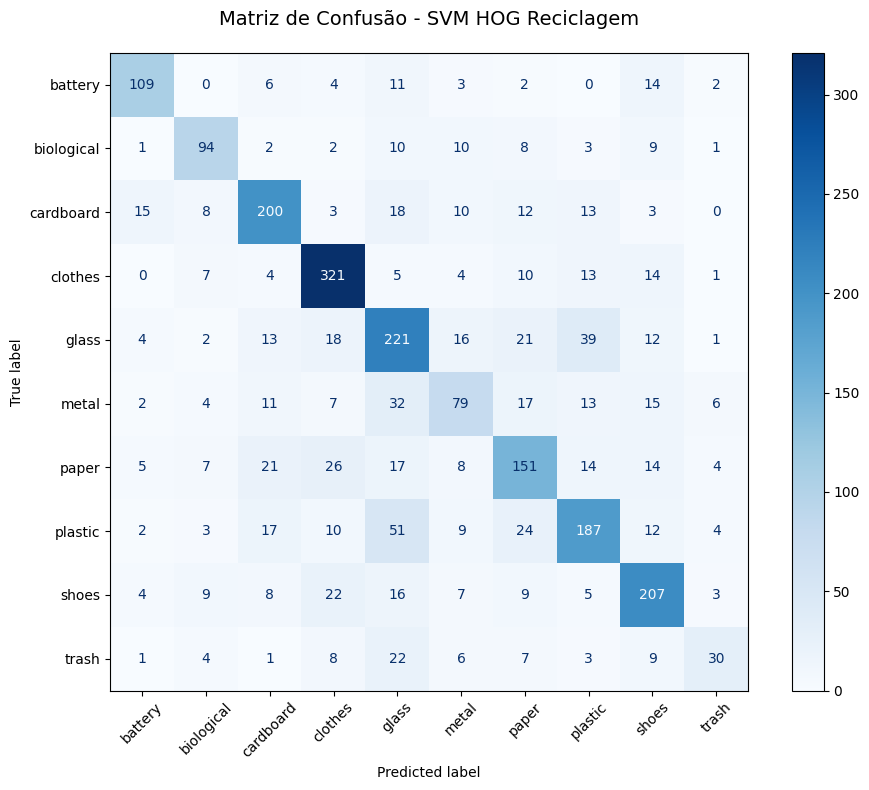

In [17]:
# ==========================================
# EXECUÇÃO PRINCIPAL (MAIN)
# ==========================================
if __name__ == "__main__":
    print("--- INICIANDO SISTEMA DE CLASSIFICAÇÃO DE RESÍDUOS SÓLIDOS (V2.0) ---")

    caminho, classes = carregar_dataset()
    X, y = extrair_features(caminho, classes)

    if len(X) > 0:
        X_train, X_test, y_train, y_test = dividir_dados(X, y)
        modelo_treinado = treinar_svm(X_train, y_train)
        predicoes = avaliar_modelo(modelo_treinado, X_test, y_test)
        plotar_matriz_confusao(y_test, predicoes, classes)
    else:
        print("\n[ERRO FATAL] Nenhuma imagem foi processada.")